In [2]:
#IMPORTS
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
# SETUP HARDWARE ACCELERATION
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# SETUP DATASETS

transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomResizedCrop(32, scale=(0.8, 1.0)), # Forces the model to learn zoom-invariant features
    v2.ToTensor(),
    v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

# Download the training and testing sets automatically
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms)

# DataLoaders handle batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


C:\Users\dackh\PycharmProjects\mediathing\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


torch.Size([64, 3, 32, 32])


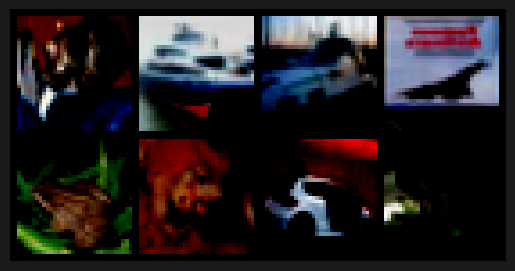

In [19]:

data_iter = iter(test_loader)
img, out = next(data_iter)
print(img.size())

grid_img = torchvision.utils.make_grid(img[:8], nrow=4, padding=2)
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [6]:
image, label = train_dataset[0]

In [7]:
image.size()

torch.Size([3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..0.9607843].


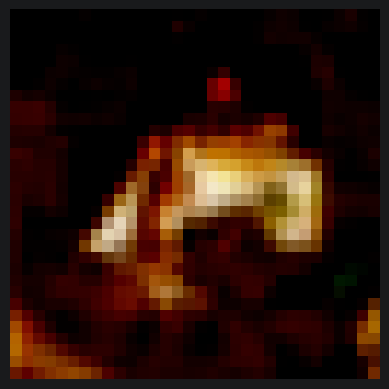

In [8]:
plt.imshow(image.permute(1, 2, 0))
plt.axis('off')
plt.show()

In [9]:
label #dog

6

In [10]:
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [16]:
# Neural network
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 channels (RGB), 32x32 image size, 5x5 kernel, output image size: 28x28
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=5)
        # Max pooling half, in 28x28 image, output 14x14 image, relu
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 6 channels, 14x14 image size, 5x5 kernel, output image size: 10x10
        self.conv2 = nn.Conv2d(in_channels=10, out_channels=15, kernel_size=5)
        # Max pooling half, in 10x10 image, output 5x5 image, relu\
        self.batchnorm = nn.BatchNorm2d(15)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(15 * 5 * 5, 120)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(120, 84)
        self.relu4 = nn.ReLU()
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool2(self.relu2(self.batchnorm(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu3(self.fc1(x)))
        x = self.relu4(self.fc2(x))
        return self.fc3(x)

In [17]:
thing_model = CNN().to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(params=thing_model.parameters(), lr=0.01, momentum=0.9, weight_decay=0.001)

In [14]:
# training
epochs = 10
print("\nBegin Training:")
for epoch in range(epochs):
    thing_model.train()
    running_loss = 0.0
    total_correct = 0.0
    total_samples = 0.0

    for images, labels in train_loader:
        # Push tensors to the same hardware device as the model
        images, labels = images.to(device), labels.to(device)

        # Zero out the gradient tracking from the last step
        optimizer.zero_grad()

        # Forward pass
        outputs = thing_model(images)
        loss = loss_func(outputs, labels)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        total_correct += (predicted == labels).sum().item()

        # Backward pass (PyTorch calculates all derivatives automatically)
        loss.backward()

        # Update our weight matrices/filters
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    accuracy = (total_correct / total_samples) * 100
    print(f"Epoch {epoch + 1}/{epochs} | Training Accuracy: {accuracy:.2f}%")
    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch + 1}/{epochs} | Training Loss: {epoch_loss:.4f}")


Begin Training:
Epoch 1/10 | Training Accuracy: 55.34%
Epoch 1/10 | Training Loss: 1.2572
Epoch 2/10 | Training Accuracy: 56.38%
Epoch 2/10 | Training Loss: 1.2298
Epoch 3/10 | Training Accuracy: 56.90%
Epoch 3/10 | Training Loss: 1.2138
Epoch 4/10 | Training Accuracy: 58.07%
Epoch 4/10 | Training Loss: 1.1913
Epoch 5/10 | Training Accuracy: 58.46%
Epoch 5/10 | Training Loss: 1.1784
Epoch 6/10 | Training Accuracy: 59.09%
Epoch 6/10 | Training Loss: 1.1595
Epoch 7/10 | Training Accuracy: 59.56%
Epoch 7/10 | Training Loss: 1.1451
Epoch 8/10 | Training Accuracy: 59.95%
Epoch 8/10 | Training Loss: 1.1360
Epoch 9/10 | Training Accuracy: 60.36%
Epoch 9/10 | Training Loss: 1.1268
Epoch 10/10 | Training Accuracy: 60.48%
Epoch 10/10 | Training Loss: 1.1179



Begin Testing:


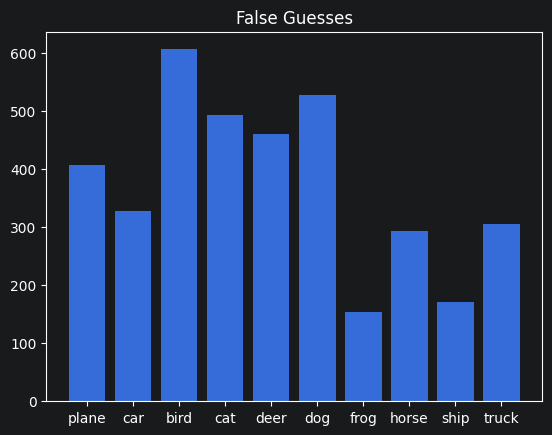

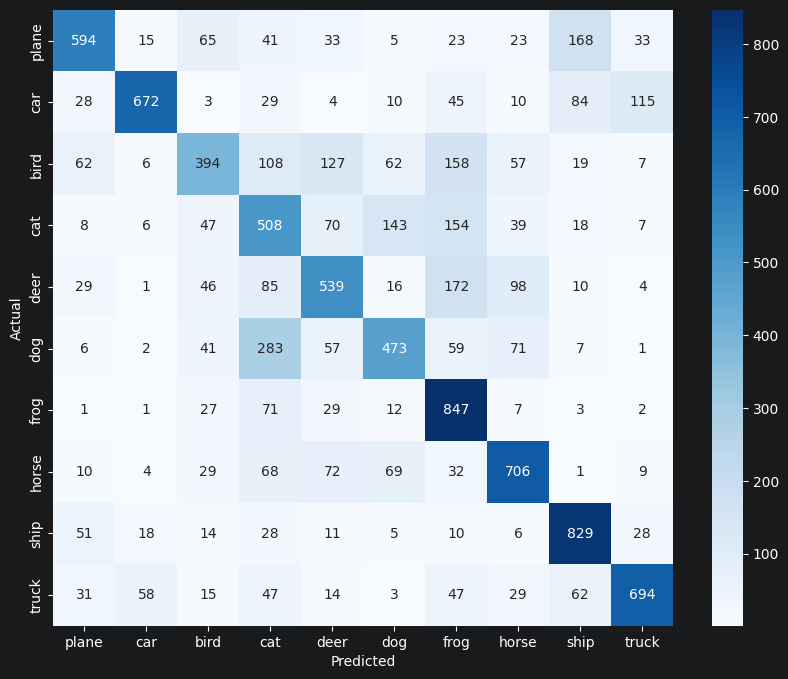

Test Accuracy on 10,000 images: 62.56%


In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Testing
print("\nBegin Testing:")
thing_model.eval()
correct = 0
total = 0
all_labels = []
all_preds = []
false_guesses = [0,0,0,0,0,0,0,0,0,0]
# Turn off gradient tracking to save memory and compute power during evaluation
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = thing_model(images)

        # Get the index of the highest logit value (this is the predicted digit)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        for i in range(len(predicted)):
            if predicted[i] != labels[i]:
                false_guesses[labels[i]] += 1
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.tolist())
        all_preds.extend(predicted.tolist())

plt.bar(class_names, false_guesses)
plt.title('False Guesses')
plt.show()

# Generate predictions for the whole test set
# (You'll need a list of all predictions and all labels)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
accuracy = 100 * correct / total
print(f"Test Accuracy on 10,000 images: {accuracy:.2f}%")

In [16]:
torch.save(thing_model.state_dict(), "models/cnn_model.pt")

In [27]:
input_tensor = torch.randn(1, 3, 32, 32)
input_tensor = input_tensor.to(device)
torch.onnx.export(thing_model,
                  (input_tensor,),
                  "models/cnn_model.onnx",
                  dynamo=True,
                  input_names=["input"])

[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `CNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


C:\Users\dackh\AppData\Local\Programs\Python\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.12.0+cu132',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,3,32,32]>
            ),
            outputs=(
                %"linear_2"<FLOAT,[1,10]>
            ),
            initializers=(
                %"conv1.weight"<FLOAT,[10,3,5,5]>{TorchTensor(...)},
                %"conv1.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.1414,  0.5486, -0.0767, -0.0574, -0.1618, -0.1578,  0.0235, -0.2580, -0.1082, -0.1689], device='cuda:0', requires_grad=True), name='conv1.bias')},
                %"conv2.weight"<FLOAT,[15,10,5,5]>{Tensor(...)},
                %"conv2.bias"<FLOAT,[15]>{Tensor(...)},
                %"fc1.weight"<FLOAT,[120,375]>{TorchTensor(...)},
                %"fc1.

In [28]:
import onnx

onnx_model = onnx.load("models/cnn_model.onnx")
onnx.checker.check_model(onnx_model)

In [23]:
import onnxruntime
import numpy as np
import torch

model = CNN()
model.load_state_dict(torch.load("models/cnn_model.pt", weights_only=True))
model.eval()

ort_session = onnxruntime.InferenceSession(
    "models/cnn_model.onnx", providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)
for i in range(30):
    image, label = test_dataset[i]

    # Use np.expand_dims to add the batch dimension at index 0
    x = np.expand_dims(image.numpy().astype(np.float32), axis=0)

    logits = ort_session.run(None, {"input": x})[0]
    pred = int(np.argmax(logits,axis=1)[0])

    torch_output = model(torch.from_numpy(x))
    print(f"Actual: {label}, Torch Predicted: {torch_output.argmax().item()}, Onnx Predicted: {pred}, "
          f"Equal: {pred == torch_output.argmax().item()}")

Actual: 3, Torch Predicted: 3, Onnx Predicted: 3, Equal: True
Actual: 8, Torch Predicted: 8, Onnx Predicted: 8, Equal: True
Actual: 8, Torch Predicted: 8, Onnx Predicted: 8, Equal: True
Actual: 0, Torch Predicted: 0, Onnx Predicted: 0, Equal: True
Actual: 6, Torch Predicted: 6, Onnx Predicted: 6, Equal: True
Actual: 6, Torch Predicted: 6, Onnx Predicted: 6, Equal: True
Actual: 1, Torch Predicted: 5, Onnx Predicted: 5, Equal: True
Actual: 6, Torch Predicted: 6, Onnx Predicted: 6, Equal: True
Actual: 3, Torch Predicted: 3, Onnx Predicted: 3, Equal: True
Actual: 1, Torch Predicted: 1, Onnx Predicted: 1, Equal: True
Actual: 0, Torch Predicted: 0, Onnx Predicted: 0, Equal: True
Actual: 9, Torch Predicted: 9, Onnx Predicted: 9, Equal: True
Actual: 5, Torch Predicted: 3, Onnx Predicted: 3, Equal: True
Actual: 7, Torch Predicted: 7, Onnx Predicted: 7, Equal: True
Actual: 9, Torch Predicted: 9, Onnx Predicted: 9, Equal: True
Actual: 8, Torch Predicted: 8, Onnx Predicted: 8, Equal: True
Actual: 